# Exoplanet Habitability Classifier
Supervised classification of potentially habitable exoplanets.
Labels from the Habitable Exoplanets Catalog (HEC).

In [59]:
import pandas as pd
import numpy as np
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import joblib

In [60]:
# Load raw NASA data
df = pd.read_csv("data/raw/nasa_exoplanets.csv", comment="#", low_memory=False)
df = df.set_index("pl_name")

# Load HEC labels
hec_names = joblib.load("data/processed/hec_names.pkl")

# Build label
df = df.copy()
df["is_habitable"] = df.index.isin(hec_names).astype(int)

print(f"Dataset : {len(df)} planets")
print(f"Habitable : {df['is_habitable'].sum()}")
print(f"Not habitable : {(df['is_habitable'] == 0).sum()}")

Dataset : 6150 planets
Habitable : 70
Not habitable : 6080


## Feature Selection
We keep only physical columns (pl_, st_, sy_) and remove :
- Metadata : reflink, solnid, str, lim, err columns
- HTML columns : archive formatting artifacts
- Constant columns : zero variance, no information
- Text columns : not usable as numerical features

In [61]:
# Keep only physical columns
physical_cols = [col for col in df.columns
                 if col.startswith(("pl_", "st_", "sy_"))]

# Remove metadata columns
clean_cols = [col for col in physical_cols
              if not any(col.endswith(s) for s in 
                         ["reflink", "solnid", "str", "lim", "err1", "err2", "symerr"])]

# Remove HTML columns
html_cols = [col for col in clean_cols
             if df[col].astype(str).str.contains("<", na=False).any()]

# Remove constant columns
constant_cols = [col for col in clean_cols
                 if df[col].nunique() <= 1]

# Remove text columns
text_cols = [col for col in clean_cols
             if df[col].dtype == object]

cols_to_drop = set(html_cols + constant_cols + text_cols)
feature_cols = [col for col in clean_cols if col not in cols_to_drop]

df_model = df[feature_cols + ["is_habitable"]].copy()

print(f"Features : {len(feature_cols)}")
print(f"Missing values : {df_model[feature_cols].isnull().sum().sum()}")

Features : 82
Missing values : 141578


In [62]:
# Remove str columns and impute in one step
str_cols = [col for col in feature_cols
            if df_model[col].apply(lambda x: isinstance(x, str)).any()]

feature_cols = [col for col in feature_cols if col not in str_cols]
df_model = df_model[feature_cols + ["is_habitable"]]

for col in feature_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

print(f"Removed str columns     : {str_cols}")
print(f"Remaining features      : {len(feature_cols)}")
print(f"Missing values          : {df_model[feature_cols].isnull().sum().sum()}")

# Train/test split
X = df_model[feature_cols]
y = df_model["is_habitable"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain : {len(X_train)} planets ({y_train.sum()} habitable)")
print(f"Test  : {len(X_test)} planets ({y_test.sum()} habitable)")

Removed str columns     : ['pl_letter', 'sy_name', 'pl_orbtper_systemref', 'pl_tranmid_systemref', 'st_metratio', 'st_spectype', 'pl_bmassprov']
Remaining features      : 75
Missing values          : 0

Train : 4920 planets (56 habitable)
Test  : 1230 planets (14 habitable)


In [63]:
# XGBoost baseline
# scale_pos_weight handles class imbalance : 6080 / 70 ≈ 87
scale = int((y_train == 0).sum() / (y_train == 1).sum())

model = XGBClassifier(
    scale_pos_weight=scale,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["not habitable", "habitable"]))
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"  True Positives  : {tp}")
print(f"  False Positives : {fp}")
print(f"  True Negatives  : {tn}")
print(f"  False Negatives : {fn}")

               precision    recall  f1-score   support

not habitable       1.00      1.00      1.00      1216
    habitable       0.79      0.79      0.79        14

     accuracy                           1.00      1230
    macro avg       0.89      0.89      0.89      1230
 weighted avg       1.00      1.00      1.00      1230

Confusion Matrix:
  True Positives  : 11
  False Positives : 3
  True Negatives  : 1213
  False Negatives : 3


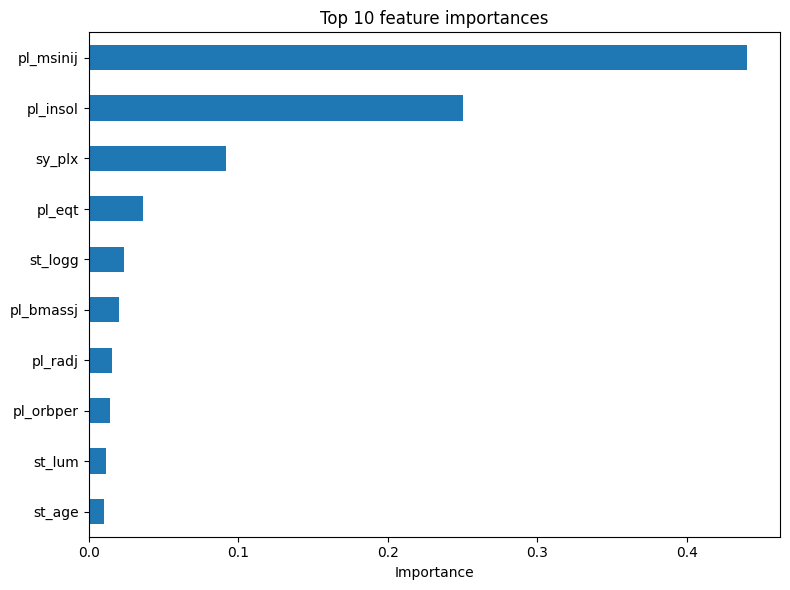

pl_msinij    0.440311
pl_insol     0.250141
sy_plx       0.092043
pl_eqt       0.036415
st_logg      0.023591
pl_bmassj    0.020489
pl_radj      0.015414
pl_orbper    0.013952
st_lum       0.011732
st_age       0.010276
dtype: float32


In [64]:
# Top 20 most important features
importances = pd.Series(model.feature_importances_, index=feature_cols)
top20 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
top20.plot(kind="barh")
plt.xlabel("Importance")
plt.title("Top 10 feature importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(top20)

##  Removing Suspicious Features
The baseline model revealed features that don't belong :
- `pl_msinij`, `pl_msinie` : minimum mass from radial velocity 
- `sy_plx`, `sy_dist` : distance 
- `pl_bmassj`, `pl_radj` : Jupiter units 
- `sy_pm`, `sy_pmra`, `sy_pmdec` : proper motion 
- `st_vsin`, `pl_rvamp` : stellar rotation and radial velocity amplitude 
- `pl_trandep`, `pl_trandur`, `pl_angsep` : transit geometry

In [ ]:
# Remove suspicious features
suspicious = [
    "pl_msinij",
    "pl_msinie", "sy_dist",
    "pl_msinijerr1", "pl_msinijerr2",  
    "pl_bmassj",   
    "pl_radj",     
    "sy_pm", "sy_pmra", "sy_pmdec",  
    "st_vsin", "pl_orbtper", "pl_orblper", "pl_rvamp", 
    "pl_trandep", "pl_trandur", "pl_angsep",
]

feature_cols_clean = [col for col in feature_cols if col not in suspicious]

X = df_model[feature_cols_clean]
y = df_model["is_habitable"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scale = int((y_train == 0).sum() / (y_train == 1).sum())

model_clean = XGBClassifier(scale_pos_weight=scale, random_state=42, eval_metric="logloss")
model_clean.fit(X_train, y_train)
y_pred = model_clean.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["not habitable", "habitable"]))
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"  True Positives  : {tp}")
print(f"  False Positives : {fp}")
print(f"  True Negatives  : {tn}")
print(f"  False Negatives : {fn}")

               precision    recall  f1-score   support

not habitable       1.00      1.00      1.00      1216
    habitable       0.85      0.79      0.81        14

     accuracy                           1.00      1230
    macro avg       0.92      0.89      0.91      1230
 weighted avg       1.00      1.00      1.00      1230

  True Positives  : 11
  False Positives : 2
  True Negatives  : 1214
  False Negatives : 3


In [66]:
importances = pd.Series(model_clean.feature_importances_, index=feature_cols_clean)
top10 = importances.sort_values(ascending=False).head(10)
print(top10)

pl_insol     0.306611
st_teff      0.290299
st_nspec     0.089085
sy_tmag      0.063174
pl_eqt       0.056918
pl_bmasse    0.033613
pl_orbper    0.027086
st_logg      0.018521
pl_rade      0.017622
st_age       0.009559
dtype: float32


## Tuning
GridSearchCV on n_estimators, max_depth, learning_rate, subsample.
5-fold cross-validation, optimizing F1.

In [67]:
param_grid = {
    "n_estimators":  [100, 300, 500],
    "max_depth":     [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample":     [0.8, 1.0],
}

grid_search = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale, random_state=42, eval_metric="logloss"),
    param_grid, scoring="f1", cv=5, n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)
print(f"Best params : {grid_search.best_params_}")
print(f"Best CV F1  : {grid_search.best_score_:.3f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'subsample': 1.0}
Best CV F1  : 0.723


In [68]:
# Best model is the baseline — F1 0.81 vs 0.71 tuned
y_pred_final = model_clean.predict(X_test)

print(classification_report(y_test, y_pred_final, target_names=["not habitable", "habitable"]))
cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()
print(f"  True Positives  : {tp}")
print(f"  False Positives : {fp}")
print(f"  True Negatives  : {tn}")
print(f"  False Negatives : {fn}")

               precision    recall  f1-score   support

not habitable       1.00      1.00      1.00      1216
    habitable       0.85      0.79      0.81        14

     accuracy                           1.00      1230
    macro avg       0.92      0.89      0.91      1230
 weighted avg       1.00      1.00      1.00      1230

  True Positives  : 11
  False Positives : 2
  True Negatives  : 1214
  False Negatives : 3


## Final Results
Our best model is the baseline. GridSearch did not improve results. (**79%** vs **72%** accuracy)
This is common with very few positive examples (70 out of 6150).
The tuned model optimizes CV score but generalizes slightly worse on the test set.